# Predict Students' Dropout and Academic Success

## Source
The dataset is sourced from the UCI Machine Learning Repository:
**Predict Students' Dropout and Academic Success**.
https://archive.ics.uci.edu/dataset/697/predict+students+dropout+and+academic+success

## Context
This real-world problem focuses on identifying students who are at risk of dropping out, allowing educational institutions to provide early intervention and support strategies.

## Target Variable
The task is a **multi-class classification problem** with three possible academic outcomes:

- **Dropout**
- **Enrolled**
- **Graduate**

## Features
The dataset contains **36 features** describing various aspects of student information, including:

### Demographic Features
Examples:
- Marital status
- Gender
- Nationality
- Age at enrollment

### Socio-Economic Features
Examples:
- Parents' occupation
- Parents' qualifications
- Scholarship holder status
- Debtor status

### Academic Performance Features
Examples:
- Curricular units approved (1st semester)
- Curricular units approved (2nd semester)
- Grades from the 1st semester
- Grades from the 2nd semester

These features help model student academic trajectories and predict educational outcomes.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.feature_selection import SelectFromModel

# 1. Loading Dataset
df = pd.read_csv('datasets/data.csv', sep=';')
df.columns = df.columns.str.strip() # Remove any whitespace from headers

# 2. Data Overview
print(f"Instances: {df.shape[0]}, Features: {df.shape[1]}")
print("\nTarget Class Distribution:")
print(df['Target'].value_counts())

Instances: 4424, Features: 37

Target Class Distribution:
Target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64


In [4]:
# Encoding target (Dropout/Enrolled/Graduate -> 0/1/2)
le = LabelEncoder()
df['Target'] = le.fit_transform(df['Target'])

X = df.drop('Target', axis=1)
y = df['Target']

# Scaling (Crucial for SVM performance)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training Set Dimension: {X_train.shape}")
print(f"Test Set Dimension: {X_test.shape}")

Training Set Dimension: (3539, 36)
Test Set Dimension: (885, 36)


In [8]:
# Identify top features using Random Forest
selector_model = RandomForestClassifier(n_estimators=100, random_state=42)
selector_model.fit(X_train, y_train)

# Select features with importance higher than the median
selector = SelectFromModel(selector_model, threshold='median')
X_train_slim = selector.fit_transform(X_train, y_train)
X_test_slim = selector.transform(X_test)

print(f"Features selected for the slim model: {X_train_slim.shape[1]}")

Features selected for the slim model: 18


In [11]:
# 1. Decision Tree with GridSearch for optimization
params_dt = {'max_depth': [3, 5, 10], 'min_samples_split': [2, 5, 10]}
grid_dt = GridSearchCV(DecisionTreeClassifier(random_state=42), params_dt, cv=5)
grid_dt.fit(X_train, y_train)
best_dt = grid_dt.best_estimator_

# 2. SVM (Simple Linear Classifier)
svm_model = SVC(kernel='linear', C=1.0, random_state=42)
svm_model.fit(X_train, y_train)

# 3. Random Forest (Ensemble Method)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

str_target_names = [str(c) for c in le.classes_]

# Evaluation on Test Set
y_pred = best_dt.predict(X_test)
print("\n--- Decision Tree Classification Report ---")
print(classification_report(y_test, y_pred, target_names=str_target_names))


--- Decision Tree Classification Report ---
              precision    recall  f1-score   support

           0       0.83      0.69      0.75       284
           1       0.56      0.34      0.42       159
           2       0.76      0.95      0.84       442

    accuracy                           0.76       885
   macro avg       0.72      0.66      0.67       885
weighted avg       0.75      0.76      0.74       885



In [16]:
from sklearn.metrics import accuracy_score

y_pred = best_dt.predict(X_test)
precise_accuracy = accuracy_score(y_test, y_pred)

print(f"Exact Accuracy: {precise_accuracy:.6f}")

Exact Accuracy: 0.755932


In [12]:
# Engineering a new feature
df_enhanced = df.copy()
df_enhanced['Academic_Average'] = (df_enhanced['Curricular units 1st sem (grade)'] +
                                   df_enhanced['Curricular units 2nd sem (grade)']) / 2

# Evaluate performance with the new feature
X_new = df_enhanced.drop('Target', axis=1)
X_tr_n, X_te_n, y_tr_n, y_te_n = train_test_split(X_new, y, test_size=0.2, random_state=42)

rf_new = RandomForestClassifier(n_estimators=100, random_state=42)
rf_new.fit(X_tr_n, y_tr_n)
new_accuracy = accuracy_score(y_te_n, rf_new.predict(X_te_n))
print(f"Accuracy with engineered feature: {new_accuracy:.4f}")

Accuracy with engineered feature: 0.7627


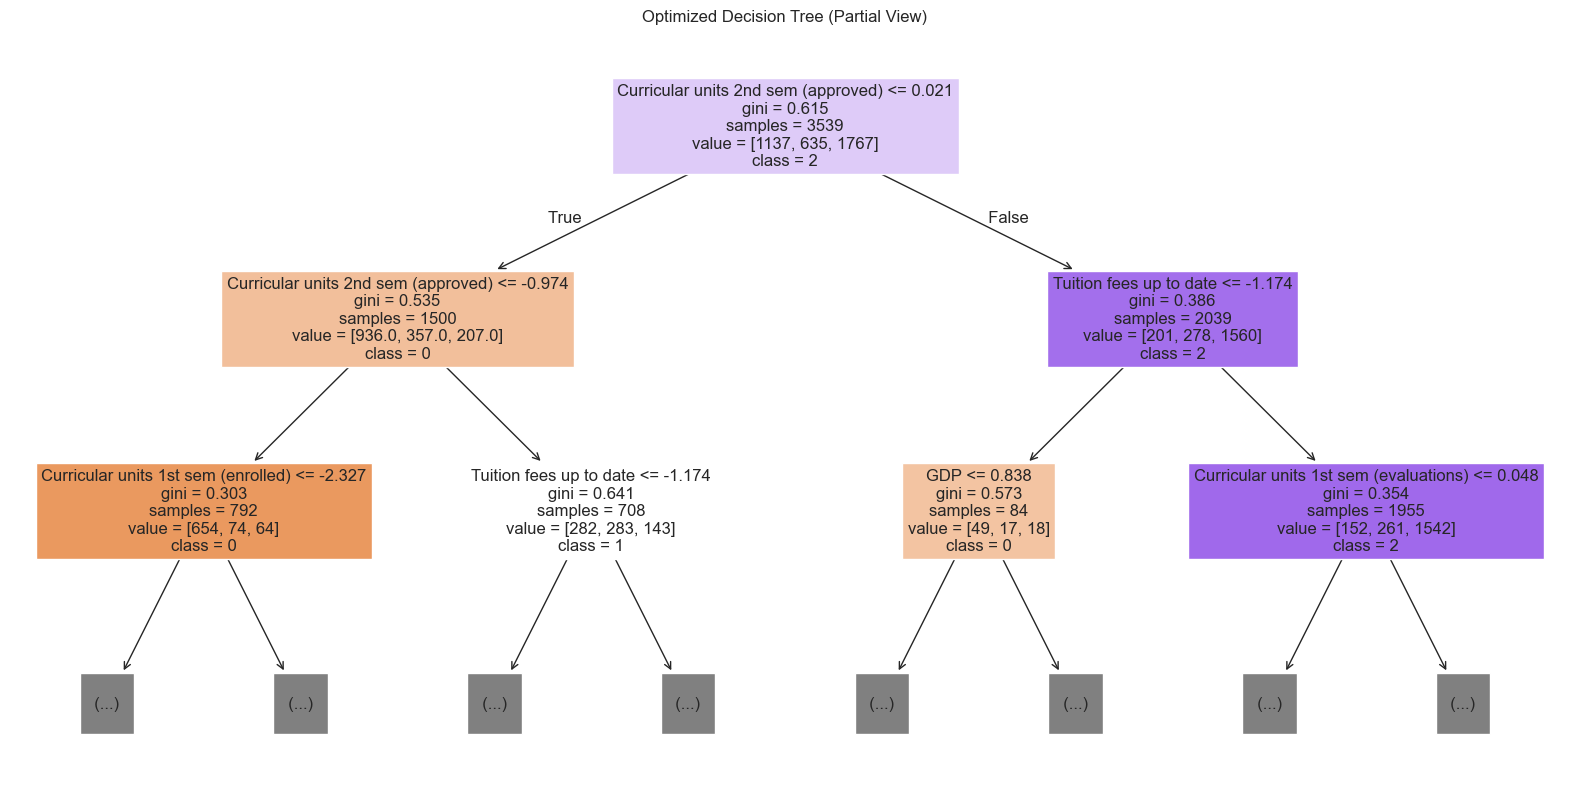

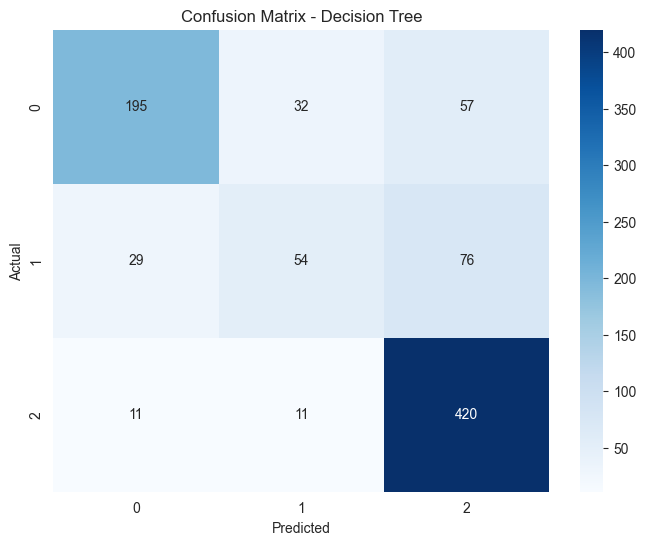

In [13]:
# Visualization 1: Decision Tree Structure
plt.figure(figsize=(20,10))
str_class_names = [str(c) for c in le.classes_]
plot_tree(best_dt, filled=True, feature_names=X.columns.tolist(),
          class_names=str_class_names, max_depth=2, fontsize=12)
plt.title("Optimized Decision Tree (Partial View)")
plt.show()

# Visualization 2: Confusion Matrix
plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Decision Tree')
plt.show()